# EDA: gigaword.tar.gz
Raw NYT Gigaword archive: 149 monthly text files (1994-07 .. 2006-12), tar+gzip, 2.4GB compressed / 6.3GB uncompressed. Each member is plain text -- HEADLINE line, blank, wrapped body paragraphs, blank-separated -- **not** sentence-per-line and **not lowercased**, unlike `train.src.tok`. Same NYT domain as the training corpus but pre-cleaning: mixed case, `-lrb-`/`-rrb-` bracket placeholders, `` ``/'' `` quotes. Streamed directly from the tar.gz (never extracted to disk) to keep memory sane, one pass over all 149 files.

In [1]:
import re
import tarfile
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Single streaming pass: paragraphs, tokens, vocab, per-file manifest

In [2]:
import os
import pickle

def paragraphs(text):
    """Blank-line-delimited paragraphs, wrapped lines rejoined -- the closest
    analog here to train.src.tok's one-sentence-per-line unit."""
    para, out = [], []
    for line in text.split('\n'):
        line = line.strip()
        if line == '':
            if para:
                out.append(' '.join(para)); para = []
        else:
            para.append(line)
    if para:
        out.append(' '.join(para))
    return out

def is_headline(p, words):
    # short, all-caps paragraph -- proxy for "start of a new article"
    if len(words) > 15:
        return False
    letters = re.sub(r'[^A-Za-z]', '', p)
    return len(letters) > 3 and letters.isupper()

CACHE = '../data/gigaword_stats_cache.pkl'  # ponytail: full pass is ~10min, cache so reruns are instant

if os.path.exists(CACHE):
    with open(CACHE, 'rb') as f:
        stats = pickle.load(f)
    n_files, n_paragraphs, n_headlines, n_tokens = stats['n_files'], stats['n_paragraphs'], stats['n_headlines'], stats['n_tokens']
    word_lens, char_lens, vocab, file_meta = stats['word_lens'], stats['char_lens'], stats['vocab'], stats['file_meta']
else:
    n_files = 0
    n_paragraphs = 0
    n_headlines = 0
    n_tokens = 0
    word_lens = []
    char_lens = []
    vocab = Counter()
    file_meta = []

    with tarfile.open('../data/gigaword.tar.gz', mode='r|gz') as tf:
        for member in tf:
            if not member.isfile():
                continue
            text = tf.extractfile(member).read().decode('utf-8', errors='replace')
            paras = paragraphs(text)
            n_files += 1
            f_tokens = 0
            for p in paras:
                words = p.split()
                if not words:
                    continue
                n_paragraphs += 1
                word_lens.append(len(words))
                char_lens.append(len(p))
                n_tokens += len(words)
                f_tokens += len(words)
                vocab.update(words)
                if is_headline(p, words):
                    n_headlines += 1
            file_meta.append((member.name, member.size, len(paras), f_tokens))

    with open(CACHE, 'wb') as f:
        pickle.dump({'n_files': n_files, 'n_paragraphs': n_paragraphs, 'n_headlines': n_headlines,
                     'n_tokens': n_tokens, 'word_lens': word_lens, 'char_lens': char_lens,
                     'vocab': vocab, 'file_meta': file_meta}, f)

print('files:', n_files)
print('paragraphs:', n_paragraphs)
print('headline-like paragraphs (~articles):', n_headlines)
print('total tokens:', n_tokens)
print('unique tokens (raw case):', len(vocab))

files: 149
paragraphs: 31320304
headline-like paragraphs (~articles): 1889071
total tokens: 1278235367
unique tokens (raw case): 2734827


## File manifest / temporal coverage

In [3]:
manifest = pd.DataFrame(file_meta, columns=['file', 'bytes', 'paragraphs', 'tokens'])
manifest['year'] = manifest['file'].str.slice(-6, -2).astype(int)
manifest['month'] = manifest['file'].str.slice(-2).astype(int)
print('date range:', manifest['file'].min(), '..', manifest['file'].max())
manifest[['bytes', 'paragraphs', 'tokens']].sum()

date range: nyt_eng_199407 .. nyt_eng_200612


bytes         6813065055
paragraphs      31320304
tokens        1278235367
dtype: int64

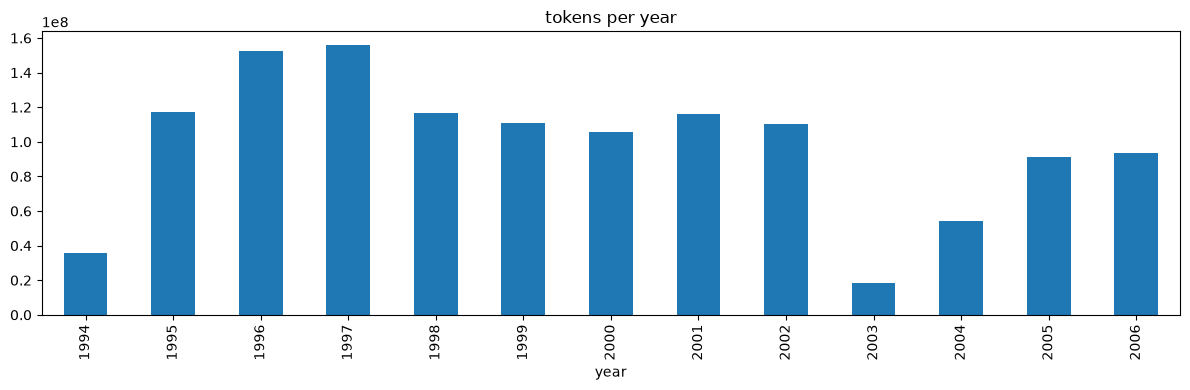

In [4]:
manifest.groupby('year')['tokens'].sum().plot.bar(figsize=(12, 4), title='tokens per year')
plt.tight_layout(); plt.show()

## Paragraph length distribution (words / chars)

In [5]:
word_lens = np.array(word_lens)
char_lens = np.array(char_lens)
pd.Series(word_lens).describe()

count    3.132030e+07
mean     4.081172e+01
std      2.748490e+01
min      1.000000e+00
25%      2.300000e+01
50%      3.800000e+01
75%      5.500000e+01
max      7.708000e+03
dtype: float64

In [6]:
pd.Series(char_lens).describe()

count    3.132030e+07
mean     2.155159e+02
std      1.446849e+02
min      1.000000e+00
25%      1.180000e+02
50%      2.020000e+02
75%      2.890000e+02
max      3.550500e+04
dtype: float64

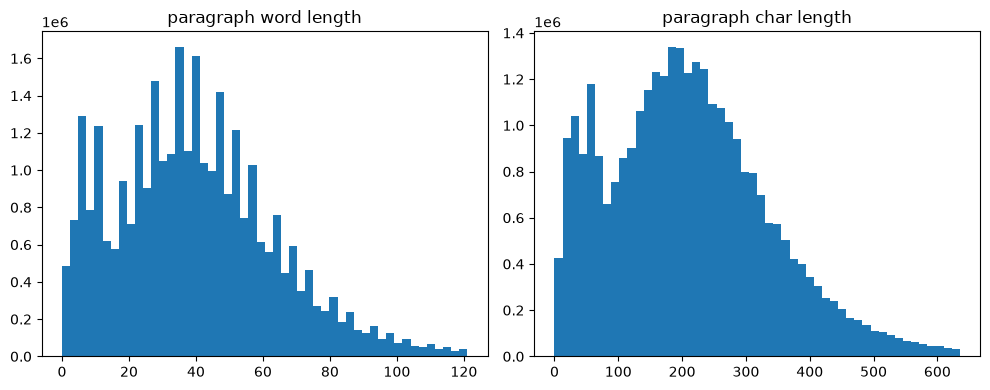

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(word_lens, bins=50, range=(0, np.percentile(word_lens, 99))); ax[0].set_title('paragraph word length')
ax[1].hist(char_lens, bins=50, range=(0, np.percentile(char_lens, 99))); ax[1].set_title('paragraph char length')
plt.tight_layout(); plt.show()

## Token category breakdown: word / number / symbol

In [8]:
def categorize(tok):
    if re.fullmatch(r'[0-9]+', tok):
        return 'number'
    if re.fullmatch(r"[a-z']+", tok, re.IGNORECASE):
        return 'word'
    return 'symbol'

cat_counts = Counter()
for tok, c in vocab.items():
    cat_counts[categorize(tok)] += c
cat_counts

Counter({'word': 1081086129, 'symbol': 183596871, 'number': 13552367})

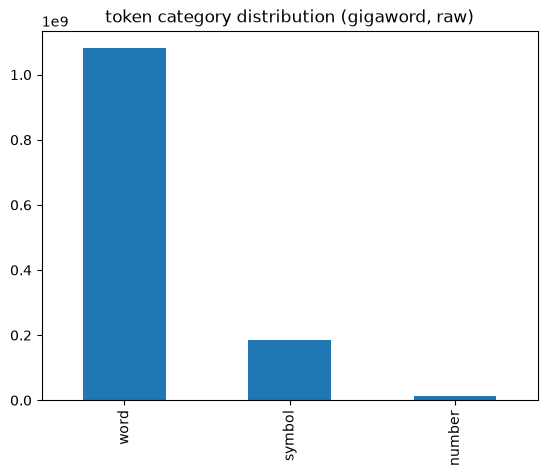

In [9]:
pd.Series(cat_counts).plot.bar(title='token category distribution (gigaword, raw)'); plt.show()

## Case distribution -- raw Gigaword is NOT lowercased, unlike train.src.tok

In [10]:
def case_bucket(tok):
    if tok.islower():
        return 'lower'
    if tok.isupper():
        return 'UPPER'
    if tok.istitle():
        return 'Title'
    return 'Mixed'

case_counts = Counter()
for tok, c in vocab.items():
    if categorize(tok) == 'word':
        case_counts[case_bucket(tok)] += c
case_counts

Counter({'lower': 884229353,
         'Title': 155460290,
         'UPPER': 24604124,
         'Mixed': 16792362})

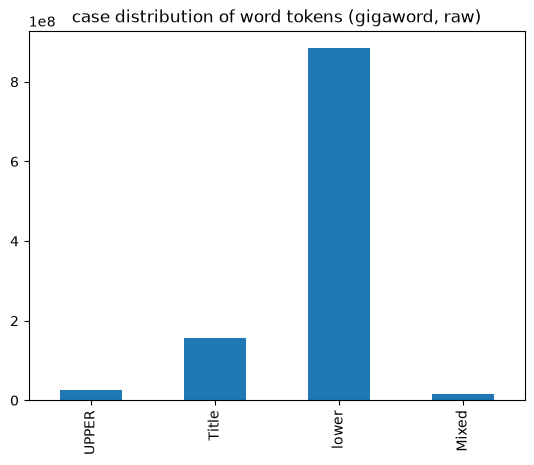

In [11]:
pd.Series(case_counts).plot.bar(title='case distribution of word tokens (gigaword, raw)'); plt.show()

## Vocabulary: most / least common tokens (raw case)

In [12]:
vocab_series = pd.Series(vocab).sort_values(ascending=False)
print('unique tokens:', len(vocab_series))
vocab_series.head(30)

unique tokens: 2734827


,       67142122
the     56792312
.       53786581
to      28095776
of      27366270
a       25857060
and     24389137
in      20167085
``      13751143
''      13580753
's      12113135
that    11979557
for     10041369
is       9946470
said     8279978
on       7643329
The      7584932
was      7002876
with     6892817
it       6592946
he       6027021
as       5924530
at       5830383
I        5160163
be       4978529
by       4883010
have     4842435
are      4795902
his      4748226
from     4742712
dtype: int64

In [13]:
vocab_series.tail(30)

hymies                      1
U.N.-like                   1
juniper-roasted             1
Heering                     1
Pan-Latino                  1
winehood                    1
Gundlach-Bund-schu          1
Ottillia                    1
Vasona                      1
-LRB-415-RRB-868-9244       1
not-so-quickly              1
Tabatchnick                 1
ParkKirk                    1
Barbecups                   1
Potsticker                  1
Turkey-Mango                1
mango-raisin                1
casserole-y                 1
Learn-to-fish               1
Chik-N-Broccoli             1
668-2221                    1
Euro-eclecticist            1
ostrich-head-in-the-sand    1
half-requited               1
Hardapple                   1
-LRB-415-RRB-243-0426       1
20184                       1
94620                       1
trimaran-type               1
Coaston                     1
dtype: int64

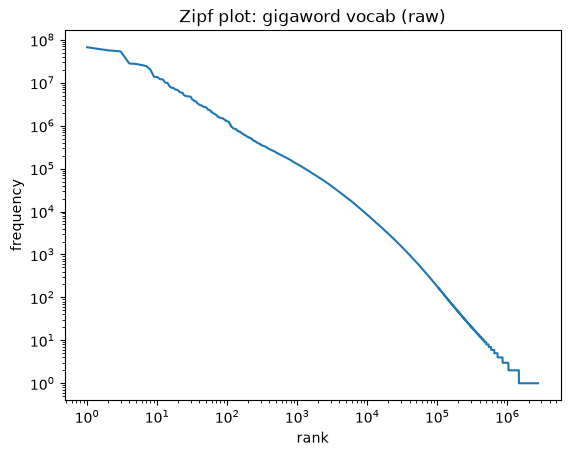

In [14]:
# Zipf check: rank vs frequency, log-log
ranks = np.arange(1, len(vocab_series) + 1)
plt.loglog(ranks, vocab_series.values)
plt.xlabel('rank'); plt.ylabel('frequency'); plt.title('Zipf plot: gigaword vocab (raw)')
plt.show()

## Special tokens / artifacts (PTB bracket placeholders, `` ''/`` quotes, headline lines)

In [15]:
special_pattern = re.compile(r'^-[a-z]+-$', re.IGNORECASE)
specials = {tok: c for tok, c in vocab.items() if special_pattern.match(tok)}
pd.Series(specials).sort_values(ascending=False).head(10)

-LRB-    3697472
-RRB-    3668813
-LCB-      29746
-LSB-      26124
-RSB-      25868
-RCB-      11687
dtype: int64

In [16]:
print("`` quote count:", vocab.get('``', 0))
print("'' quote count:", vocab.get("''", 0))
print('headline-like paragraphs (~articles):', n_headlines, '/', n_paragraphs, 'paragraphs')
print('avg paragraphs per article:', round(n_paragraphs / n_headlines, 1))

`` quote count: 13751143
'' quote count: 13580753
headline-like paragraphs (~articles): 1889071 / 31320304 paragraphs
avg paragraphs per article: 16.6


## Vocab overlap: raw gigaword vs cleaned train.src.tok / dev / test vocab

In [17]:
vocab_lower = Counter()
for tok, c in vocab.items():
    vocab_lower[tok.lower()] += c
print('unique tokens, lowercased:', len(vocab_lower))

unique tokens, lowercased: 2396141


In [18]:
train_vocab = set()
with open('../data/train.src.tok', encoding='utf-8') as f:
    for line in f:
        train_vocab.update(line.split())

gw_vocab = set(vocab_lower.keys())
print('gigaword vocab (lowered):', len(gw_vocab))
print('train.src.tok vocab:', len(train_vocab))
print('train tokens covered by gigaword:', len(train_vocab & gw_vocab), '/', len(train_vocab),
      '(%.1f%%)' % (100 * len(train_vocab & gw_vocab) / len(train_vocab)))
print('gigaword tokens also in train vocab:', len(gw_vocab & train_vocab), '/', len(gw_vocab),
      '(%.1f%%)' % (100 * len(gw_vocab & train_vocab) / len(gw_vocab)))

gigaword vocab (lowered): 2396141
train.src.tok vocab: 99021
train tokens covered by gigaword: 93077 / 99021 (94.0%)
gigaword tokens also in train vocab: 93077 / 2396141 (3.9%)


In [19]:
import json
with open('../data/dev_token_list.json') as f:
    dev_words = set(json.load(f))
with open('../data/test_token_list.json') as f:
    test_words = set(json.load(f))

print('dev answer tokens in gigaword vocab:', len(dev_words & gw_vocab), '/', len(dev_words))
print('test context tokens in gigaword vocab:', len(test_words & gw_vocab), '/', len(test_words))

dev answer tokens in gigaword vocab: 10257 / 10310
test context tokens in gigaword vocab: 43524 / 44450


## Masked vocab: number -> `1`, lowercase (train.src.tok-style tokenization)
Apply the same masking planned for the final training vocab: lowercase everything (reuses `vocab_lower` above), then collapse every pure-digit token (the `categorize() == 'number'` bucket) into a single `1` token. Rare-word masking (`[UNK]`) is decided next by coverage threshold, not applied yet.

In [20]:
vocab_masked = Counter()
for tok, c in vocab_lower.items():
    if categorize(tok) == 'number':
        vocab_masked['1'] += c
    else:
        vocab_masked[tok] += c

print('unique tokens after number-masking:', len(vocab_masked))
print("'1' (masked number) occurrences:", vocab_masked['1'])

unique tokens after number-masking: 2375543
'1' (masked number) occurrences: 13552367


## Vocab size needed for N% cumulative coverage
Sort tokens by frequency descending; find how many top tokens are needed so their cumulative occurrence count covers 95% / 97.5% / 99% / 99.99% of all tokens. Everything outside that kept set becomes `[UNK]` in the final tokenization.

In [21]:
counts_sorted = np.array(sorted(vocab_masked.values(), reverse=True))
total = counts_sorted.sum()
cum = np.cumsum(counts_sorted) / total

rows = []
for thresh in [0.95, 0.975, 0.99, 0.9999]:
    n_keep = int(np.searchsorted(cum, thresh) + 1)
    n_unk_types = len(counts_sorted) - n_keep
    unk_occurrences = total - counts_sorted[:n_keep].sum()
    rows.append({
        'coverage': thresh,
        'vocab_size_kept': n_keep,
        'types_masked_to_unk': n_unk_types,
        'unk_occurrences': int(unk_occurrences),
        'unk_occurrence_pct': round(100 * unk_occurrences / total, 4),
    })

coverage_table = pd.DataFrame(rows)
coverage_table

,coverage,vocab_size_kept,types_masked_to_unk,unk_occurrences,unk_occurrence_pct
0,0.9500,17907,2357636,63909638,4.9998
1,0.9750,38692,2336851,31955199,2.4999
2,0.9900,103118,2272425,12782298,1.0000
3,0.9999,2247720,127823,127823,0.0100


## Coverage curve: vocab size vs. cumulative occurrence coverage

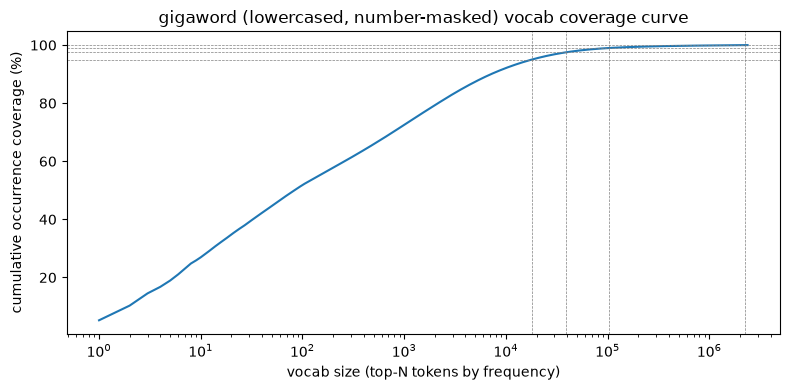

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(cum) + 1), cum * 100)
for thresh in [0.95, 0.975, 0.99, 0.9999]:
    n_keep = int(np.searchsorted(cum, thresh) + 1)
    plt.axhline(thresh * 100, color='gray', linewidth=0.5, linestyle='--')
    plt.axvline(n_keep, color='gray', linewidth=0.5, linestyle='--')
plt.xscale('log')
plt.xlabel('vocab size (top-N tokens by frequency)')
plt.ylabel('cumulative occurrence coverage (%)')
plt.title('gigaword (lowercased, number-masked) vocab coverage curve')
plt.tight_layout(); plt.show()